In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

from sarimax import plot_target
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima.arima import auto_arima

from sarima import plot_target
from sarima import multitarget_sarima

import itertools
from tqdm.auto import tqdm


import os

C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## From 1992

In [16]:
#Prepare data
from pathlib import Path

data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns = {"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports", "Exports", "USDPHP", "NominalGDP_disagg", "Pop_disagg", 
                     "COVID-19", "TRAIN","CREATE","FIST","BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

# Convert Date to datetime
target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"] )

# Filter both to start from 1992-01-01
target = target[target["Date"] >= "1992-01-01"]
features = features[features["Date"] >= "1992-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")

# Replace NaN values with 0
features = features.fillna(0)

In [17]:
TARGETS = {
    "aggregated": {
        "features": ["Non-tax Revenues", "Expenditures","Tax Revenues", "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["Tax Revenues", "Expenditures"],
    },
    "disaggregated": {
        "features": ["BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures",
                     "TotalTrade_PHPMN", "NominalGDP_disagg", "Pop_disagg", "USDPHP"],
        "labels":   ["Tax Revenues", "BIR", "BOC", "Other Offices", "Expenditures"],
    },
}

FEATURE_CONFIGS = {
    # Config 1: All numerical + lagged + dummy
    "num_lag_dummy": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  False,
    },
    # Config 2: All numerical + lagged + COVID-19 only
    "num_lag_covid": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  False,
    },
    # Config 3: All numerical + lagged + dummy + seasonal
    "num_lag_dummy_seasonal": {
        "dummy_vars":    ["COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"],
        "use_seasonal":  True,
    },
    # Config 4: All numerical + lagged + COVID-19 + seasonal
    "num_lag_covid_seasonal": {
        "dummy_vars":    ["COVID-19"],
        "use_seasonal":  True,
    },
}

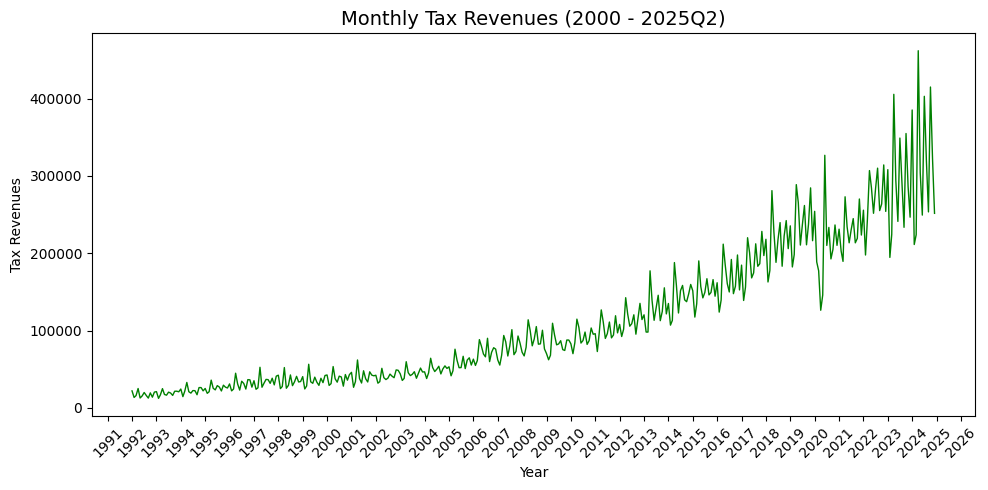

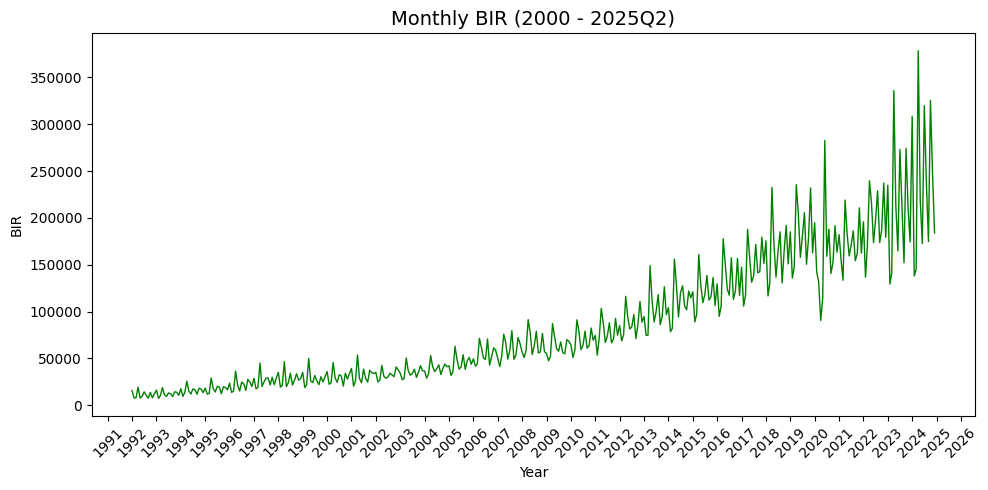

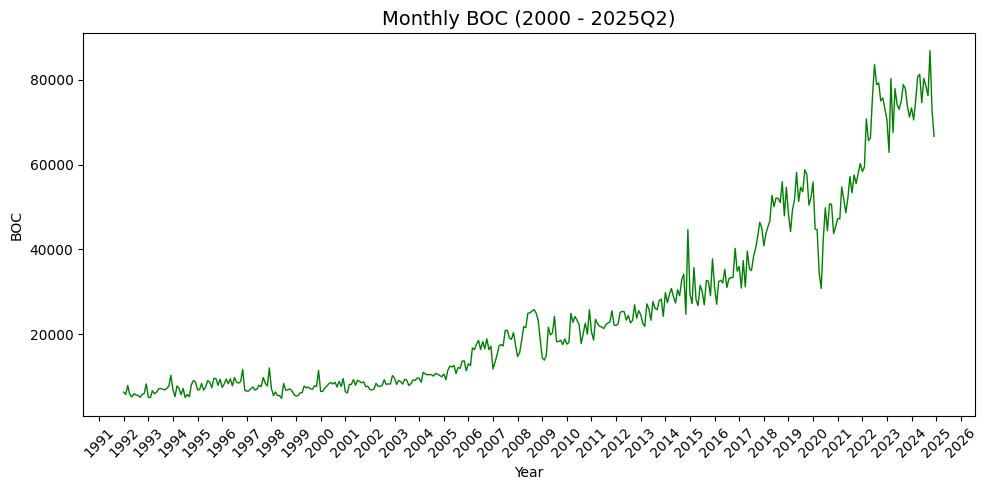

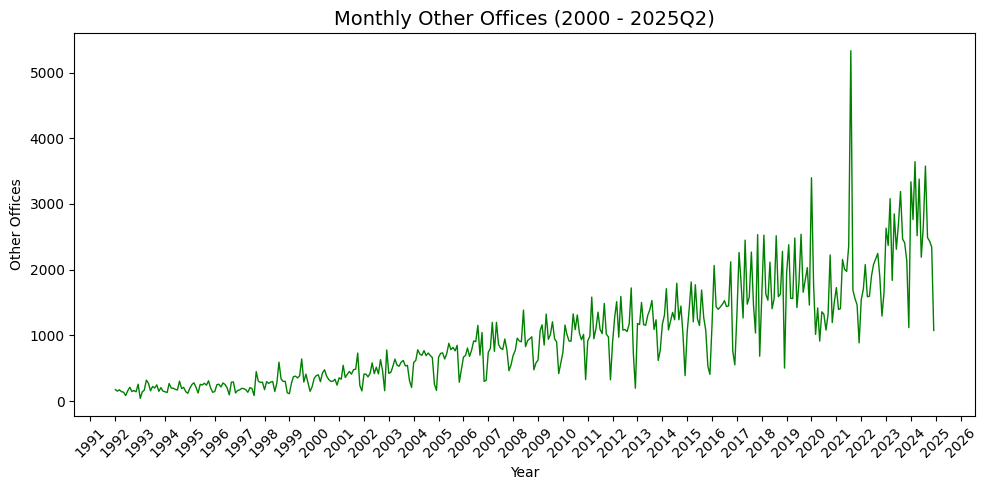

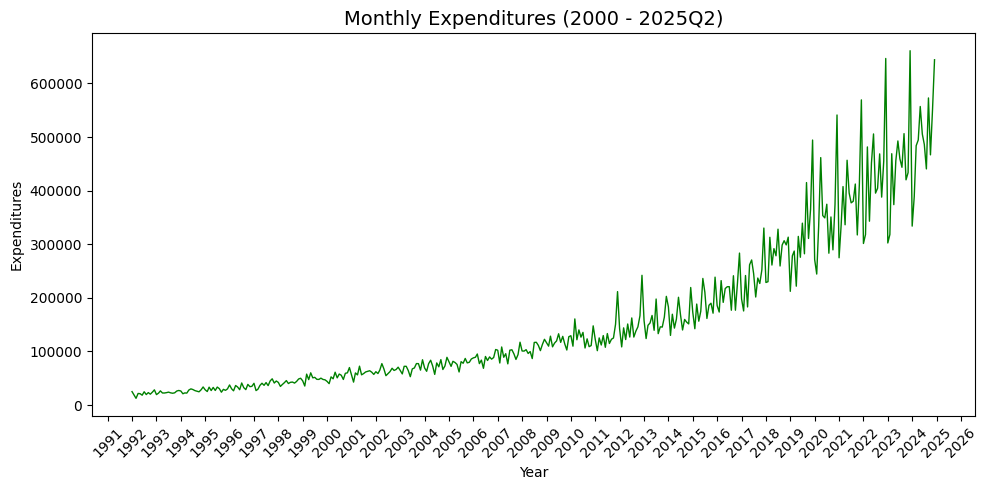

In [18]:
for x in TARGETS["disaggregated"]["labels"]:
    plot_target(target, x)

In [19]:
# Split data
test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]


In [20]:
records = []

for x in TARGETS["disaggregated"]["labels"]:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())           # D=1, s=12
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())  # d=1, D=1, s=12

    records.append({
        'Variable': x,
        'Level p-value': round(level[1], 4),
        'Level Stationary': level[1] < 0.05,
        'First Diff p-value': round(first_diff[1], 4),
        'First Diff Stationary': first_diff[1] < 0.05,
        'Second Diff p-value': round(second_diff[1], 4),
        'Second Diff Stationary': second_diff[1] < 0.05,
        'Seasonal Diff p-value': round(seasonal_diff[1], 4),
        'Seasonal Diff Stationary': seasonal_diff[1] < 0.05,
        'Seasonal Double Diff p-value': round(seasonal_double_diff[1], 4),
        'Seasonal Double Diff Stationary': seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index('Variable')

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Tax Revenues,1.0,False,0.2394,False,0.0,True,0.9692,False,0.0,True
BIR,1.0,False,0.4227,False,0.0,True,0.9434,False,0.0,True
BOC,1.0,False,0.0182,True,0.0,True,0.6496,False,0.0,True
Other Offices,1.0,False,0.0000,True,0.0,True,0.0002,True,0.0,True
Expenditures,1.0,False,0.0001,True,0.0,True,0.5958,False,0.0,True


### Order Specification

In [21]:
diff_tax_train = train["Tax Revenues"].diff().diff().dropna()
diff_BIR_train = train["BIR"].diff().diff().dropna()
diff_BOC_train = train["BOC"].diff().dropna()
diff_other_offices_train = train["Other Offices"].diff().dropna()
diff_expenditure_train = train['Expenditures'].diff().dropna()

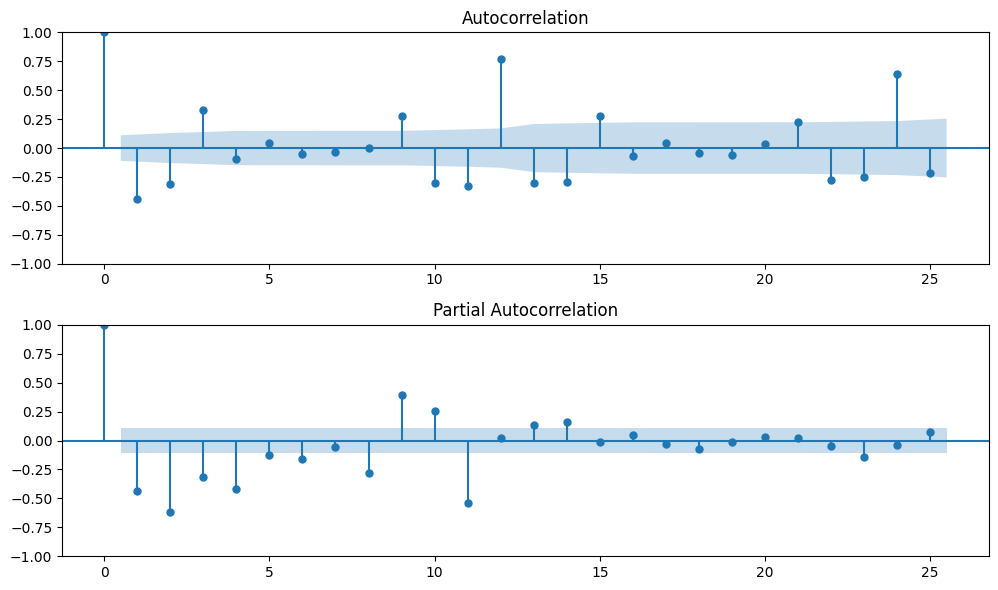

In [22]:
#Tax
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_tax_train).dropna(), ax=ax[0])
plot_pacf((diff_tax_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 4 max q = 3 max d = 2 max D = 1 max Q = 2 max P = 1

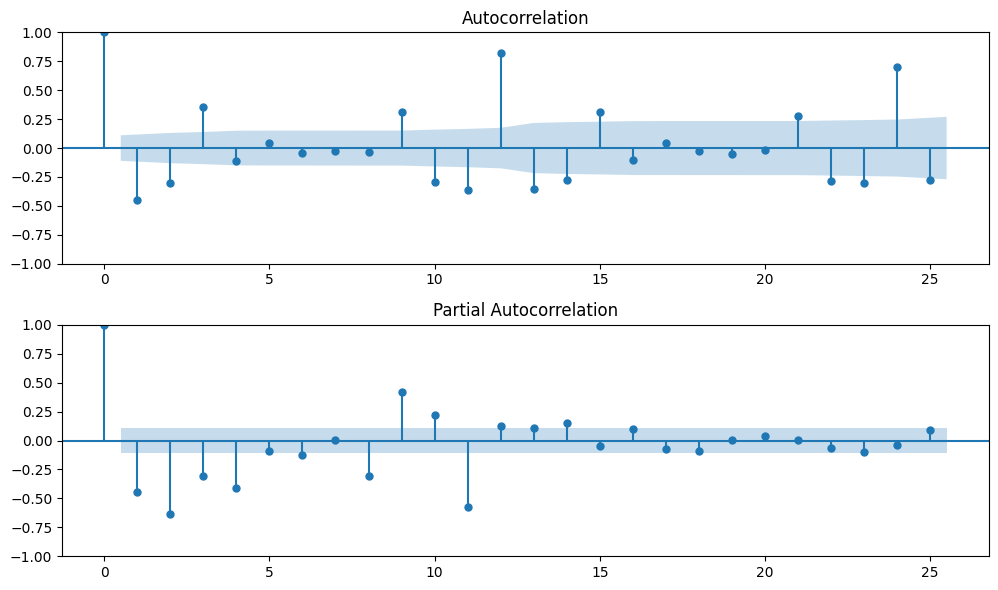

In [23]:
#BIR
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_BIR_train).dropna(), ax=ax[0])
plot_pacf((diff_BIR_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 4 max q = 3 max d = 2 max D = 1 max Q = 2 max P = 1

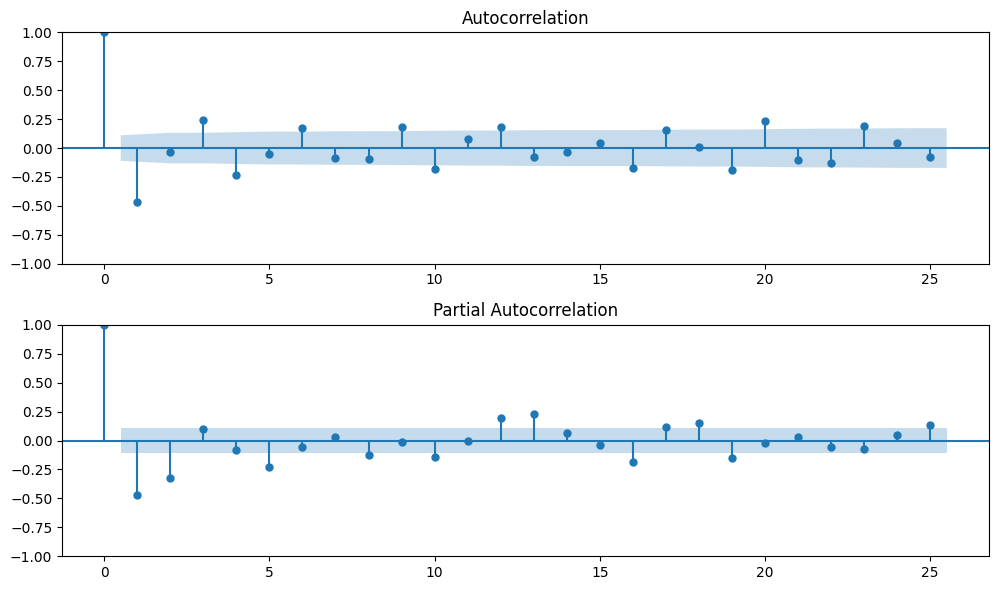

In [24]:
#BOC
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_BOC_train).dropna(), ax=ax[0])
plot_pacf((diff_BOC_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 2 max q = 3 max d = 1 max D = 1 max Q = 0 max P = 1

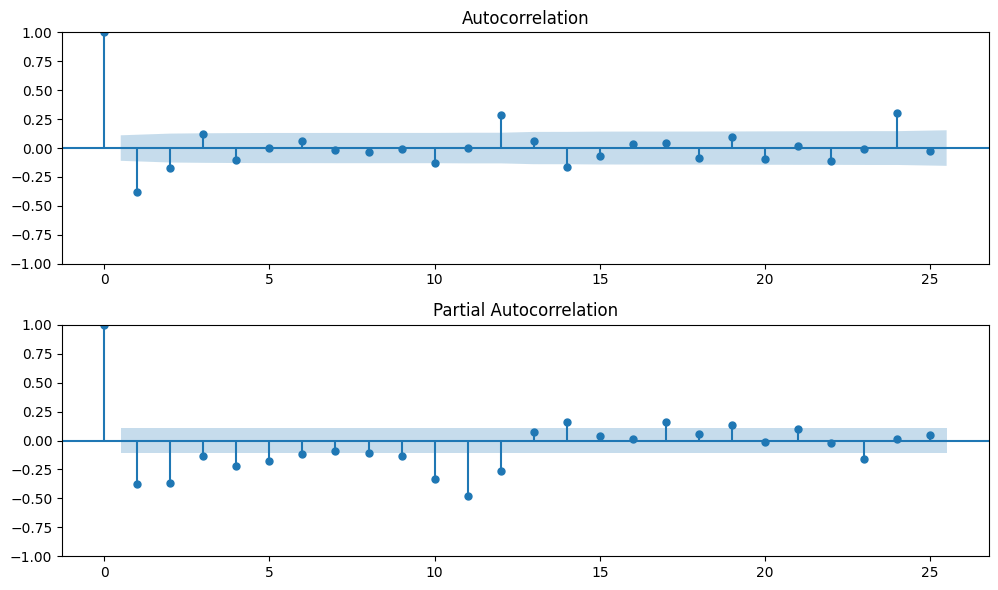

In [25]:
#Other Offices
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_other_offices_train).dropna(), ax=ax[0])
plot_pacf((diff_other_offices_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 6 max q = 2 max d = 1 max D = 1 max Q = 2 max P = 1

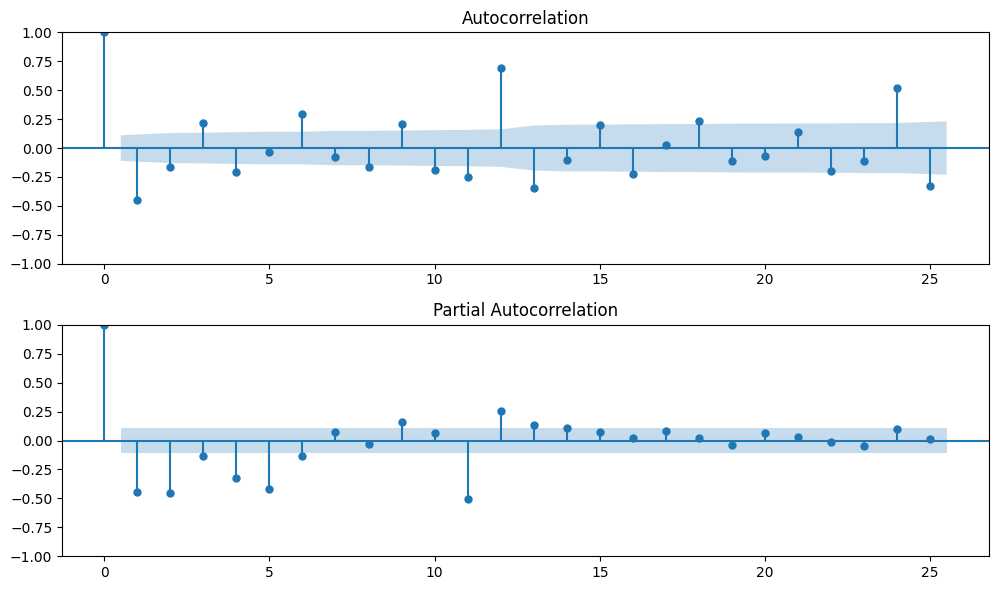

In [26]:
#Expenditures Train
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf((diff_expenditure_train).dropna(), ax=ax[0])
plot_pacf((diff_expenditure_train).dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

# max p = 6 max q = 4 max d = 1 max D = 1 max Q = 2 max P = 1

In [27]:
tax_train = train["Tax Revenues"]
bir_train = train["BIR"]
boc_train = train["BOC"]
others_train = train["Other Offices"]
expenditure_train = train['Expenditures']
tax_test = test["Tax Revenues"]
bir_test = test["BIR"]
boc_test = test["BOC"]
others_test = test["Other Offices"]
expenditure_test = test['Expenditures']

In [28]:
macro_train = feat_train[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
macro_test = feat_test[["Imports","Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]

In [29]:
labels = TARGETS["disaggregated"]["labels"]

bounds_map = {
    "Tax Revenues":    {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BIR":             {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BOC":             {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 1, "D_max": 1, "Q_min": 0, "Q_max": 0},
    "Other Offices":   {"p_min": 0, "p_max": 6, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Expenditures":    {"p_min": 0, "p_max": 6, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 4, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
}

best_models_df, all_trials_df, forecasts_df, fitted_models = multitarget_sarima(
    train_df=train,
    test_df=test,
    exog_train=macro_train,
    exog_test=macro_test,
    labels=labels,
    bounds_map=bounds_map,
    seasonal_period=12,
    verbose=True,
    n_jobs=  max(1, (os.cpu_count() or 2) - 1)
    )

display(best_models_df)
display(forecasts_df.head())

[Tax Revenues] candidates: 240
[BIR] candidates: 240
[BOC] candidates: 24
[Other Offices] candidates: 252
[Expenditures] candidates: 420


Labels completed:   0%|          | 0/5 [00:00<?, ?it/s]

[BOC] done: 24/24, converged=24


Labels completed:  20%|██        | 1/5 [06:00<24:00, 360.24s/it]

[Other Offices] progress: 50/252
[Expenditures] progress: 50/420
[Tax Revenues] progress: 50/240
[BIR] progress: 50/240
[Other Offices] progress: 100/252
[Expenditures] progress: 100/420
[Tax Revenues] progress: 100/240
[BIR] progress: 100/240
[Other Offices] progress: 150/252
[Expenditures] progress: 150/420
[Tax Revenues] progress: 150/240
[BIR] progress: 150/240
[Other Offices] progress: 200/252
[Expenditures] progress: 200/420
[Tax Revenues] progress: 200/240
[BIR] progress: 200/240
[Other Offices] progress: 250/252
[Other Offices] done: 252/252, converged=252


...

Labels completed:  80%|████████  | 4/5 [3:40:34<44:30, 2670.61s/it]  

[Expenditures] progress: 250/420
[Expenditures] progress: 300/420
[Expenditures] progress: 350/420
[Expenditures] progress: 400/420


[Expenditures] done: 420/420, converged=420


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
BOC,"(2, 1, 0)","(1, 1, 0, 12)",5349.968882,15220.179237,17383.885347,25.460046
Other Offices,"(2, 1, 2)","(0, 1, 2, 12)",3797.441563,502.109979,656.317819,30.349757
BIR,"(1, 1, 3)","(1, 1, 2, 12)",5524.173755,41358.436877,49715.145037,24.068431
Tax Revenues,"(2, 2, 3)","(1, 1, 2, 12)",5637.085289,68430.249494,82958.555262,29.185087
Expenditures,"(2, 1, 4)","(0, 1, 2, 12)",6007.711661,58982.826227,77189.705864,13.685349


,BOC,Other Offices,BIR,Tax Revenues,Expenditures
Date,,,,,
2018-06-01,50034.546918,2054.327334,155167.202006,206444.384547,310827.577489
2018-07-01,50212.357293,1973.829527,166181.854143,224232.357801,294103.179012
2018-08-01,51228.141875,2314.739039,189152.100430,238592.403428,240592.140004
2018-09-01,53159.396402,1952.522617,165655.298688,219183.853477,279883.080741
2018-10-01,55631.461595,2075.800509,166357.174856,226908.018209,269649.796990


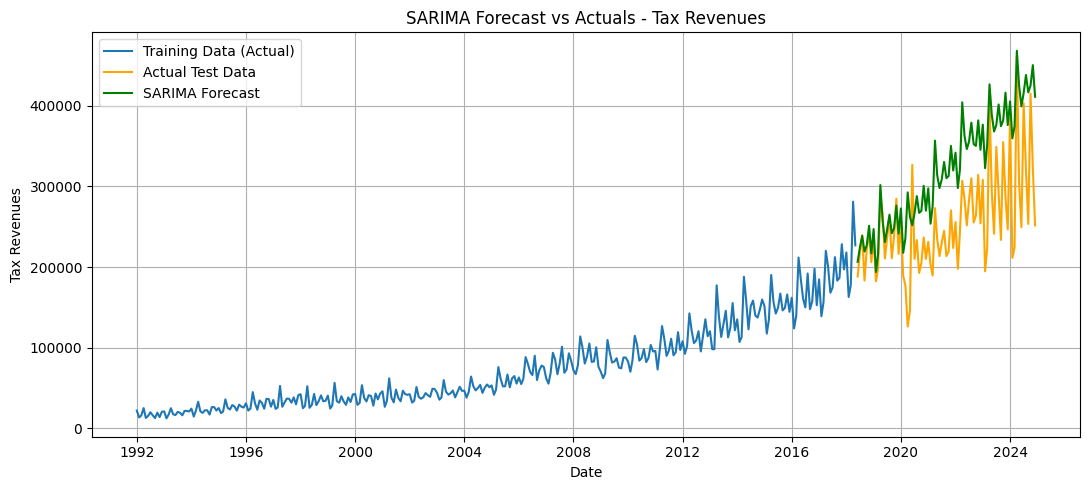

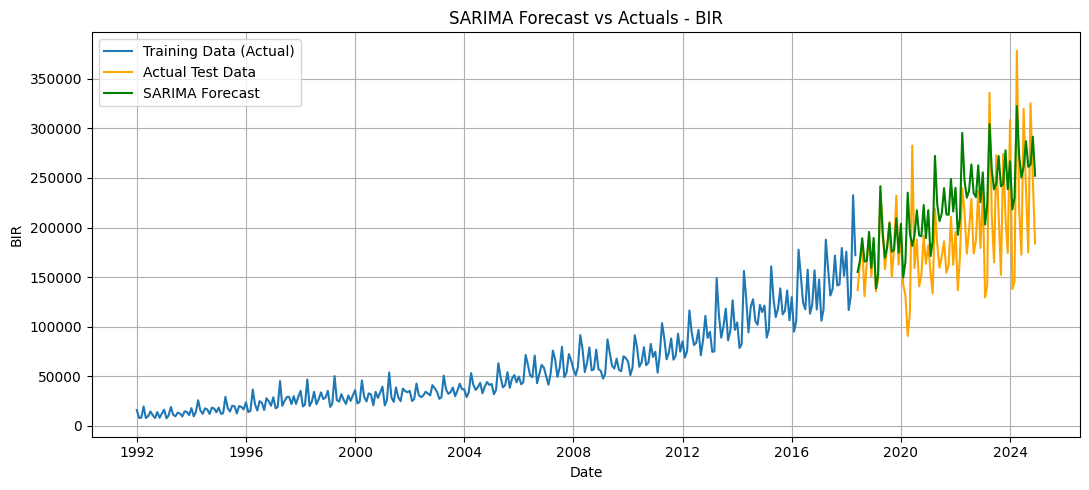

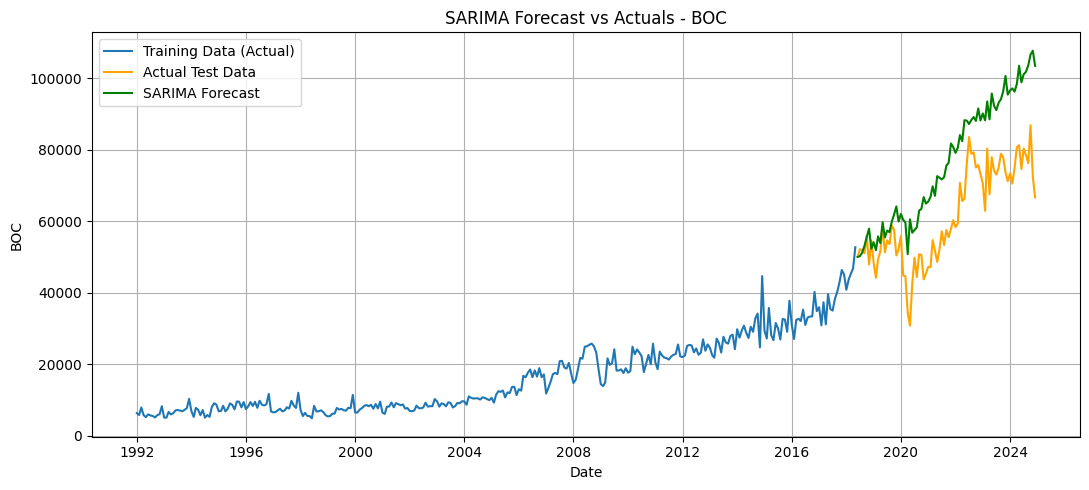

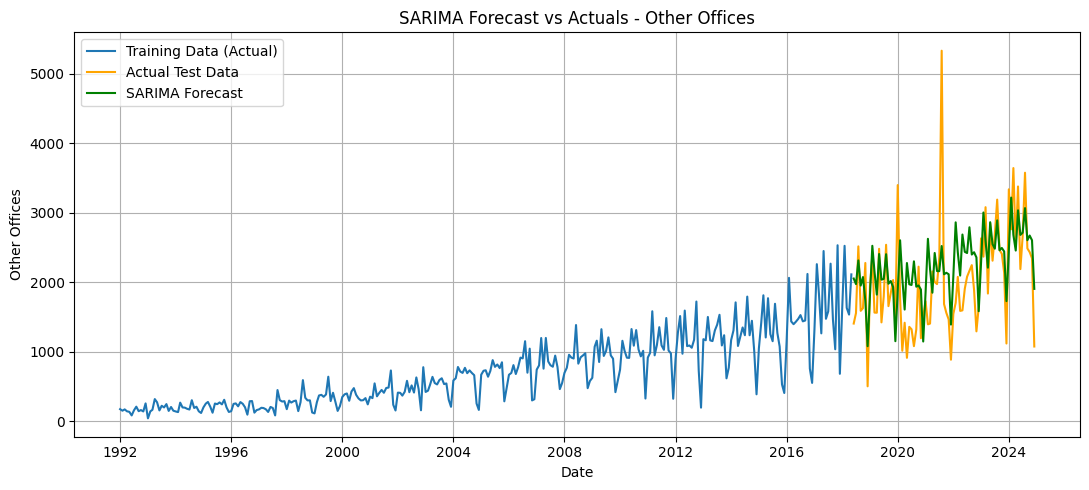

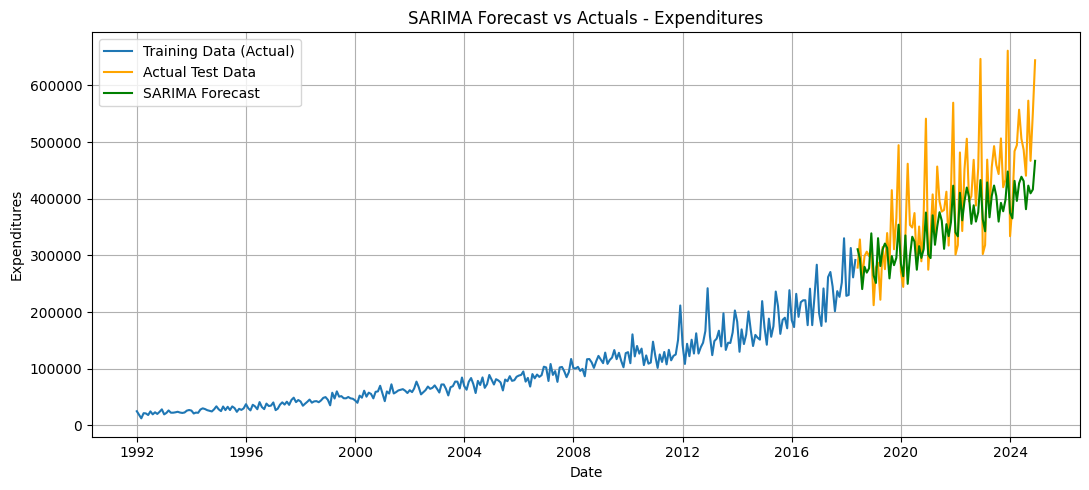

In [30]:
labels_to_plot = [lbl for lbl in labels if lbl in train.columns and lbl in test.columns and lbl in forecasts_df.columns]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train.index, train[lbl], label="Training Data (Actual)")
    plt.plot(test.index, test[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## For 2000

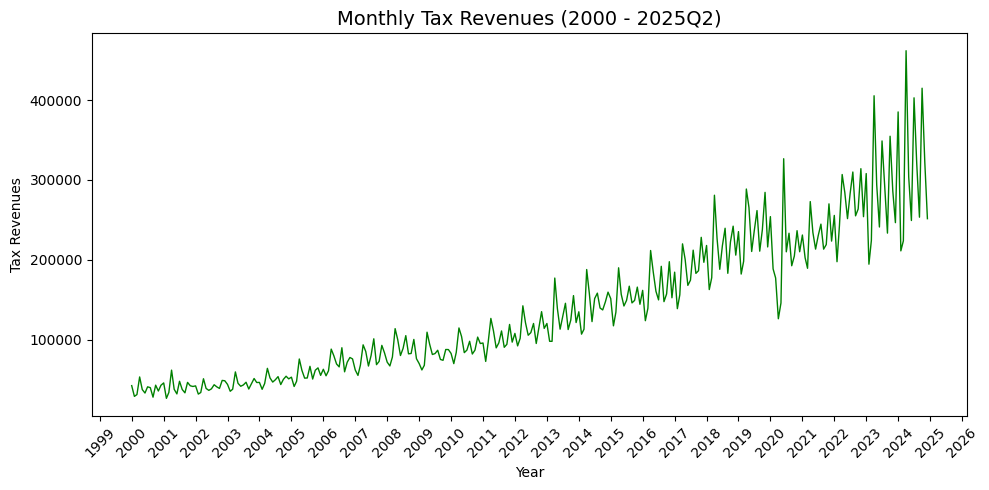

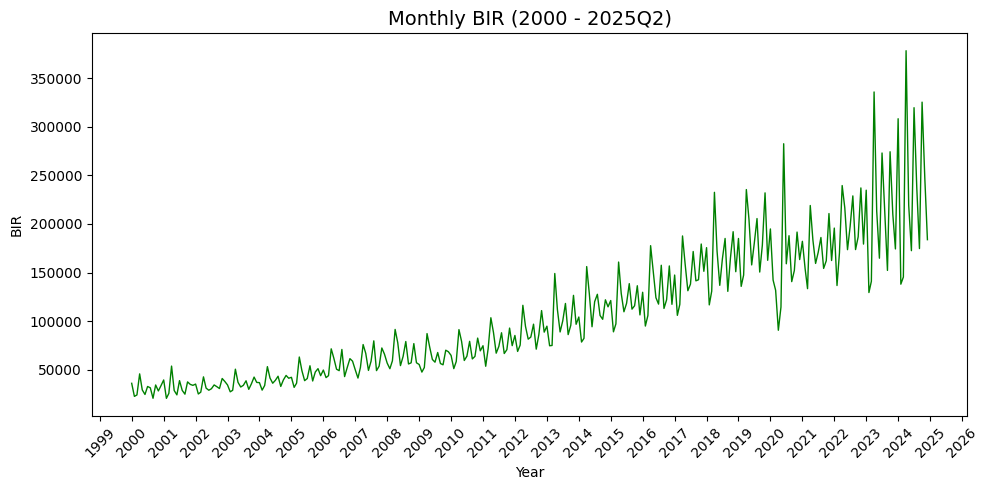

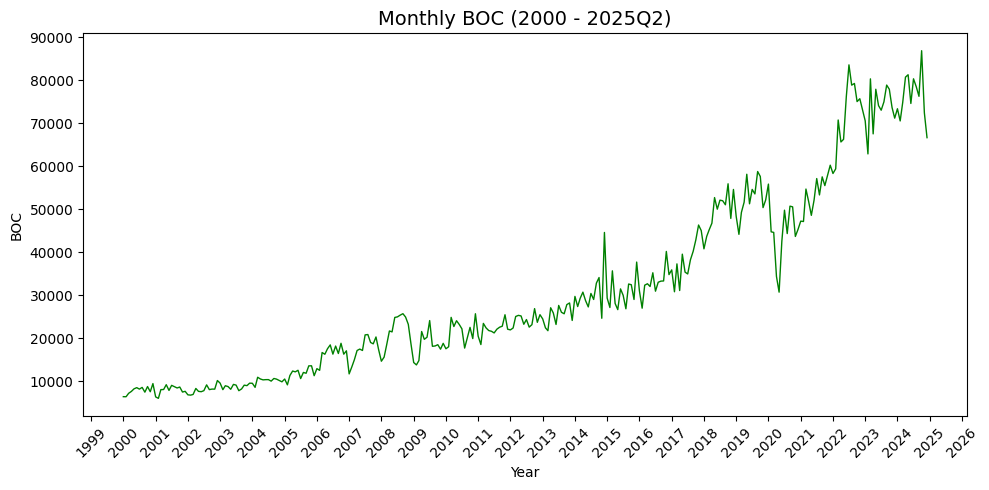

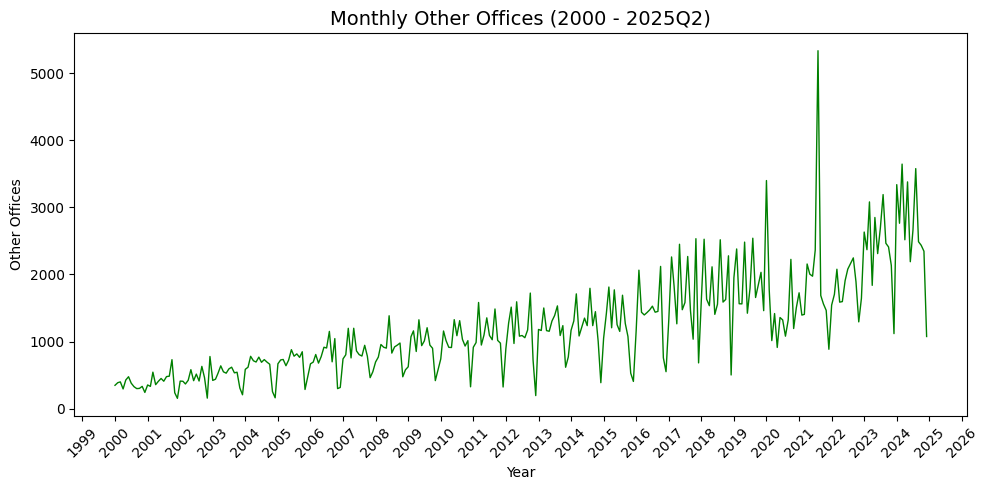

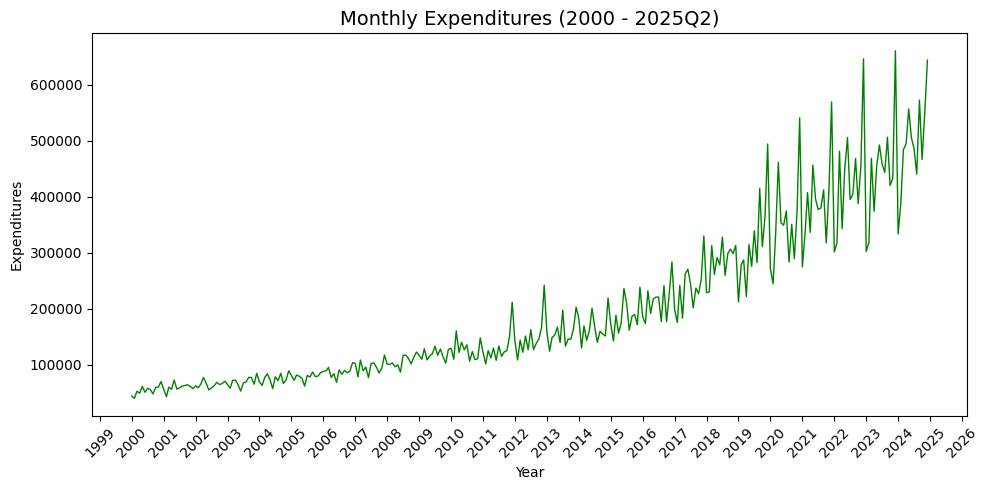

In [5]:
# Prepare data (duplicated from For 1992 section)
from pathlib import Path

data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns={"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports", "Exports", "USDPHP", "NominalGDP_disagg", "Pop_disagg",
                     "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"])

target = target[target["Date"] >= "2000-01-01"]
features = features[features["Date"] >= "2000-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")
features = features.fillna(0)

for x in TARGETS["disaggregated"]["labels"]:
    plot_target(target, x)

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]

records = []



In [6]:
for x in TARGETS["disaggregated"]["labels"]:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index("Variable")


,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Tax Revenues,1.0000,False,0.1019,False,0.0,True,0.5032,False,0.0,True
BIR,1.0000,False,0.0977,False,0.0,True,0.6459,False,0.0,True
BOC,0.9954,False,0.0004,True,0.0,True,0.0773,False,0.0,True
Other Offices,0.9967,False,0.0000,True,0.0,True,0.0003,True,0.0,True
Expenditures,1.0000,False,0.0084,True,0.0,True,0.8343,False,0.0,True


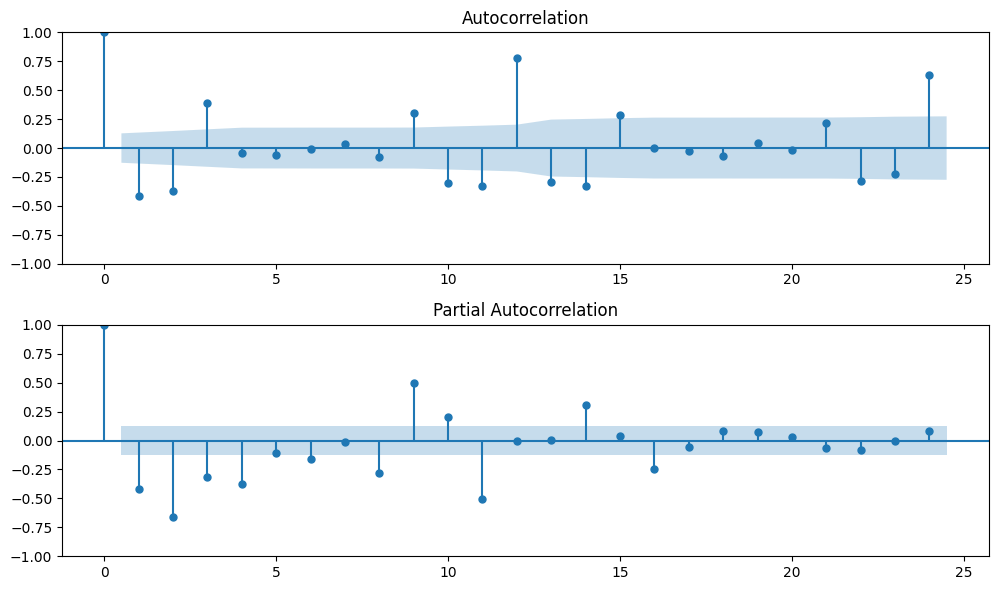

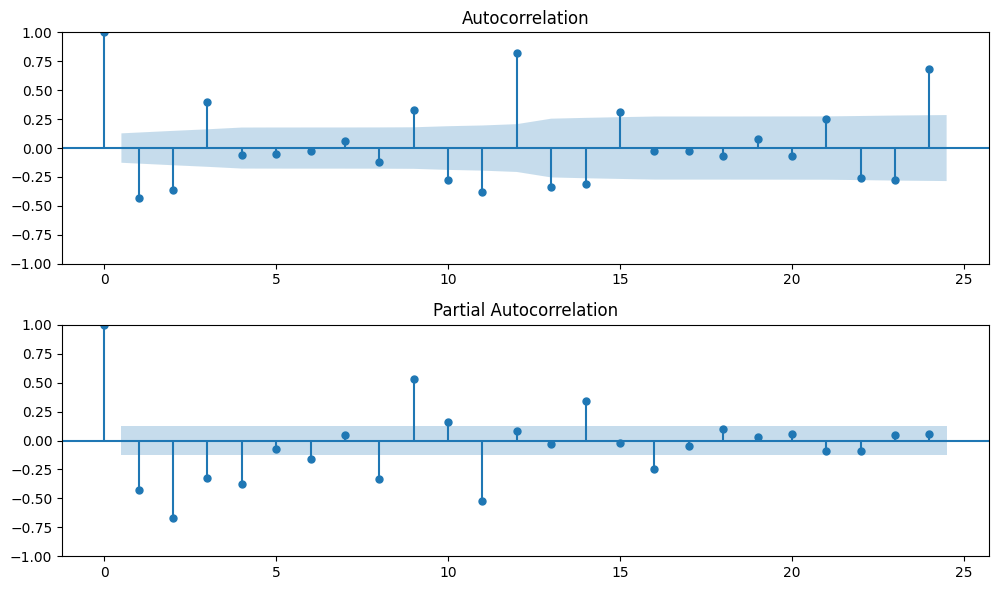

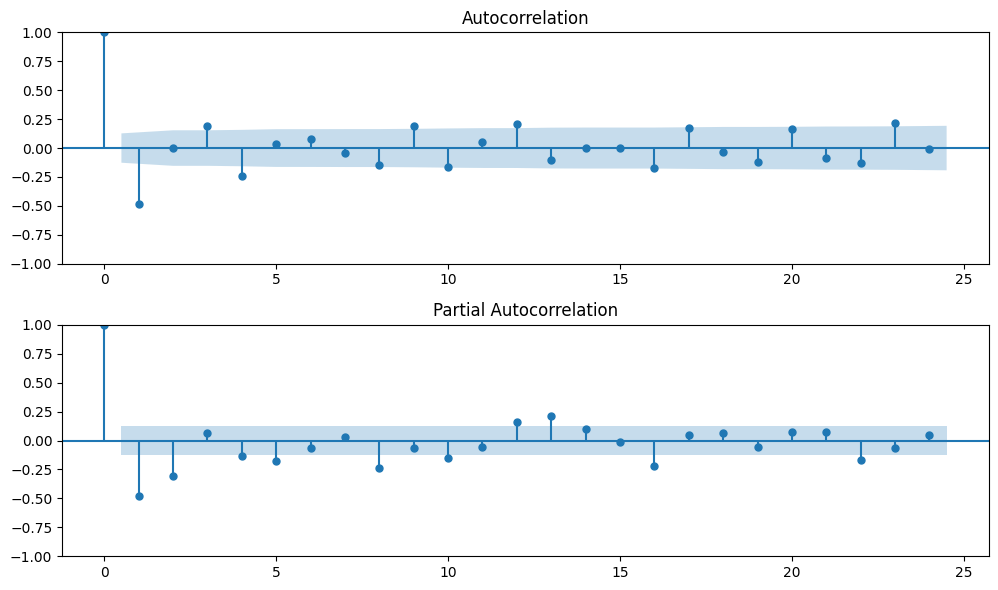

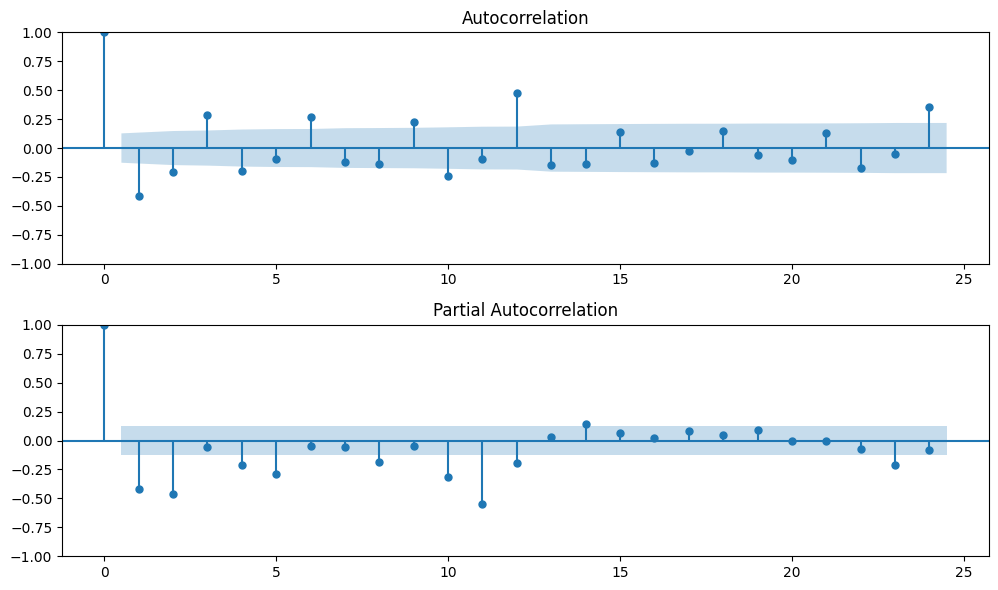

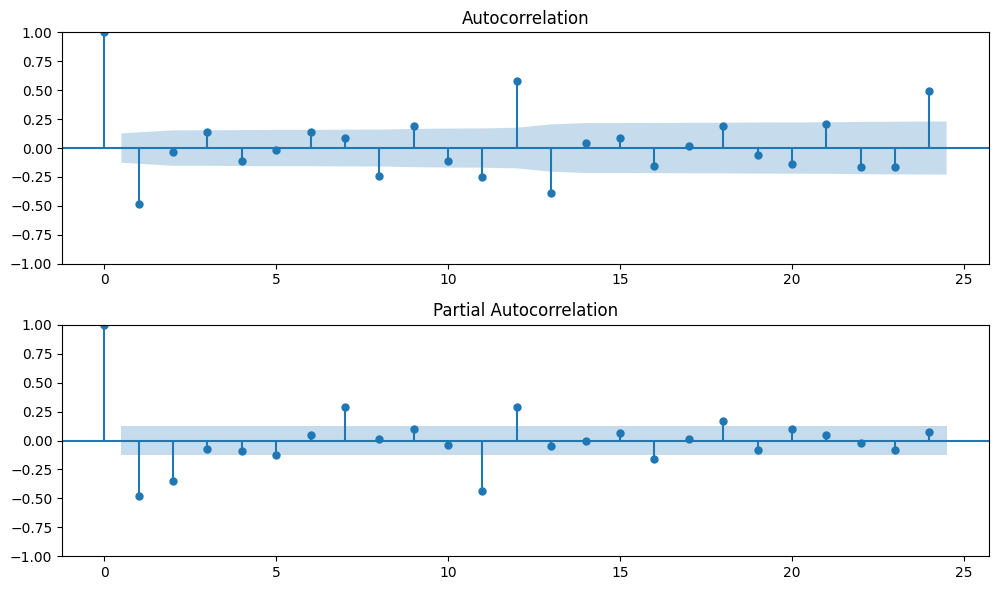

In [7]:
diff_tax_train = train["Tax Revenues"].diff().diff().dropna()
diff_BIR_train = train["BIR"].diff().diff().dropna()
diff_BOC_train = train["BOC"].diff().dropna()
diff_other_offices_train = train["Other Offices"].diff().dropna()
diff_expenditure_train = train["Expenditures"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_tax_train.dropna(), ax=ax[0])
plot_pacf(diff_tax_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BIR_train.dropna(), ax=ax[0])
plot_pacf(diff_BIR_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BOC_train.dropna(), ax=ax[0])
plot_pacf(diff_BOC_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_other_offices_train.dropna(), ax=ax[0])
plot_pacf(diff_other_offices_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_expenditure_train.dropna(), ax=ax[0])
plot_pacf(diff_expenditure_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()


In [8]:
tax_train = train["Tax Revenues"]
bir_train = train["BIR"]
boc_train = train["BOC"]
others_train = train["Other Offices"]
expenditure_train = train["Expenditures"]
tax_test = test["Tax Revenues"]
bir_test = test["BIR"]
boc_test = test["BOC"]
others_test = test["Other Offices"]
expenditure_test = test["Expenditures"]

macro_train = feat_train[["Imports", "Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
macro_test = feat_test[["Imports", "Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]

labels = TARGETS["disaggregated"]["labels"]

bounds_map = {
    "Tax Revenues":  {"p_min": 0, "p_max": 4, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BIR":           {"p_min": 0, "p_max": 4, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "BOC":           {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Other Offices": {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 3, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 2},
    "Expenditures":  {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

best_models_df, all_trials_df, forecasts_df, fitted_models = multitarget_sarima(
    train_df=train,
    test_df=test,
    exog_train=macro_train,
    exog_test=macro_test,
    labels=labels,
    bounds_map=bounds_map,
    seasonal_period=12,
    verbose=True,
    n_jobs=max(1, (os.cpu_count() or 2) - 1),
)

display(best_models_df)
display(forecasts_df.head())

[Tax Revenues] candidates: 240
[BIR] candidates: 240
[BOC] candidates: 216
[Other Offices] candidates: 432
[Expenditures] candidates: 144


Labels completed:   0%|          | 0/5 [00:00<?, ?it/s]

[Expenditures] progress: 50/144
[Other Offices] progress: 50/432
[BOC] progress: 50/216
[Tax Revenues] progress: 50/240
[BIR] progress: 50/240
[Expenditures] progress: 100/144
[Other Offices] progress: 100/432
[BOC] progress: 100/216
[Tax Revenues] progress: 100/240
[BIR] progress: 100/240
[Expenditures] done: 144/144, converged=144


Labels completed:  20%|██        | 1/5 [24:17<1:37:08, 1457.01s/it]

[BOC] progress: 150/216
[Other Offices] progress: 150/432
[Tax Revenues] progress: 150/240
[BIR] progress: 150/240
[Other Offices] progress: 200/432
[BOC] progress: 200/216
[BIR] progress: 200/240
[BOC] done: 216/216, converged=216


...

Labels completed:  80%|████████  | 4/5 [50:23<09:04, 544.71s/it]   

[Tax Revenues] done: 240/240, converged=240
[Other Offices] progress: 300/432
[Other Offices] progress: 350/432
[Other Offices] progress: 400/432


[Other Offices] done: 432/432, converged=432


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Expenditures,"(2, 2, 1)","(2, 1, 0, 12)",4580.716077,188828.145436,213167.947242,45.649020
BOC,"(2, 1, 0)","(2, 1, 1, 12)",3755.502539,8356.981487,10049.103485,12.496626
BIR,"(2, 2, 3)","(1, 1, 2, 12)",4098.807478,71172.622942,79928.130559,41.797828
Tax Revenues,"(2, 2, 3)","(1, 1, 2, 12)",4155.651693,74178.841660,82836.092096,31.617290
Other Offices,"(1, 1, 3)","(1, 1, 2, 12)",2803.264227,660.051865,813.148776,38.869999


,Expenditures,BOC,BIR,Tax Revenues,Other Offices
Date,,,,,
2020-01-01,336624.605871,51773.019198,201326.288695,259649.302579,1833.761295
2020-02-01,354262.994009,45136.678600,162353.742403,212089.427478,2531.061303
2020-03-01,401145.128338,49640.167403,172989.191063,222181.488043,1907.717103
2020-04-01,271796.447759,40103.814299,241852.892593,287248.149599,1520.866429
2020-05-01,372643.981453,46110.158177,216194.175364,268303.792031,2311.633552


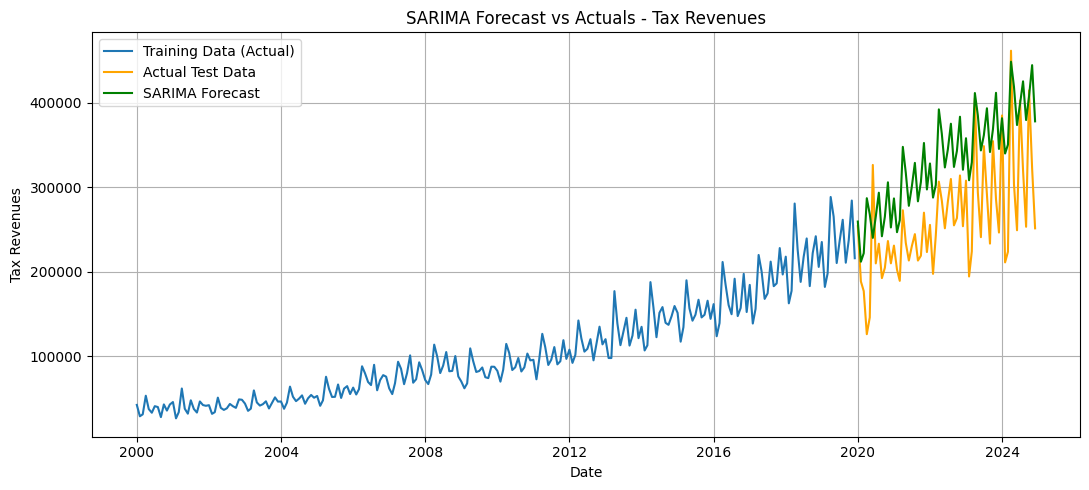

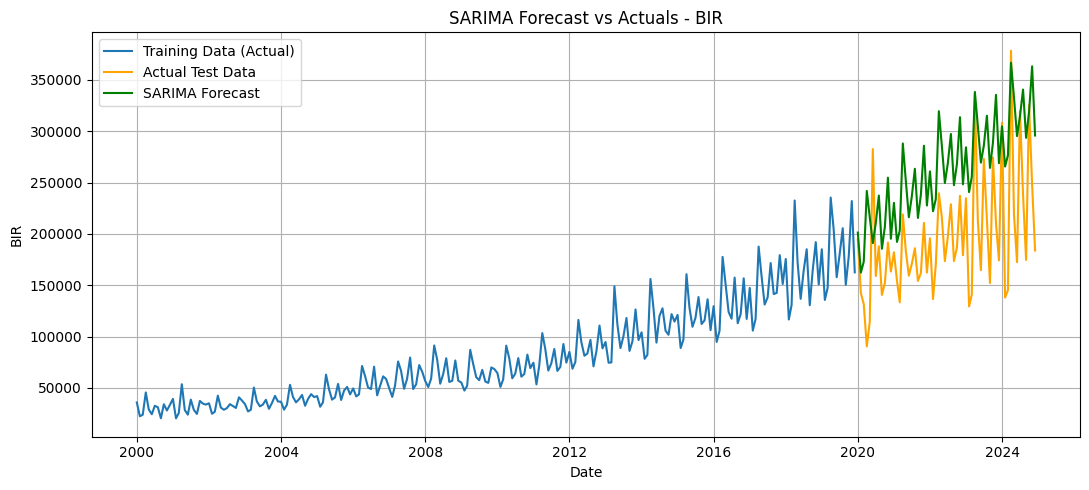

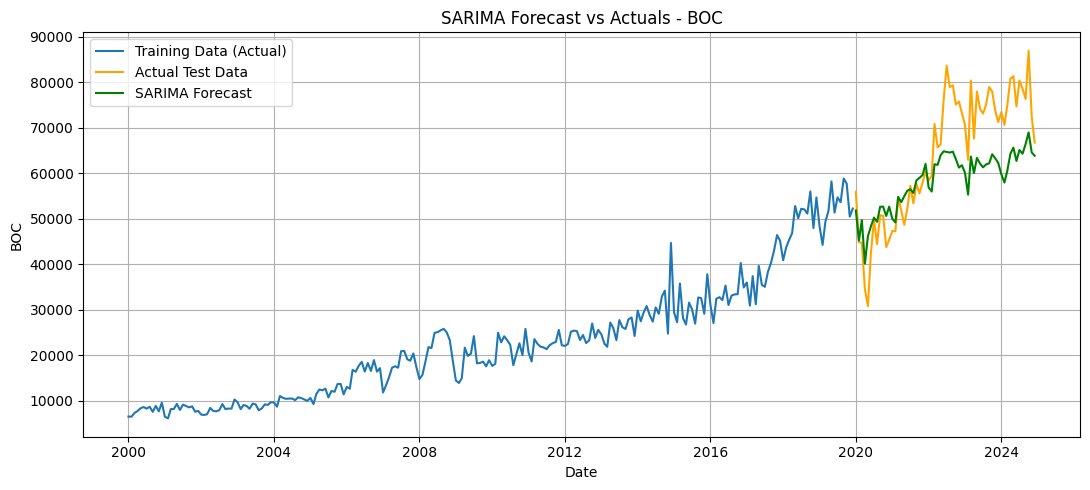

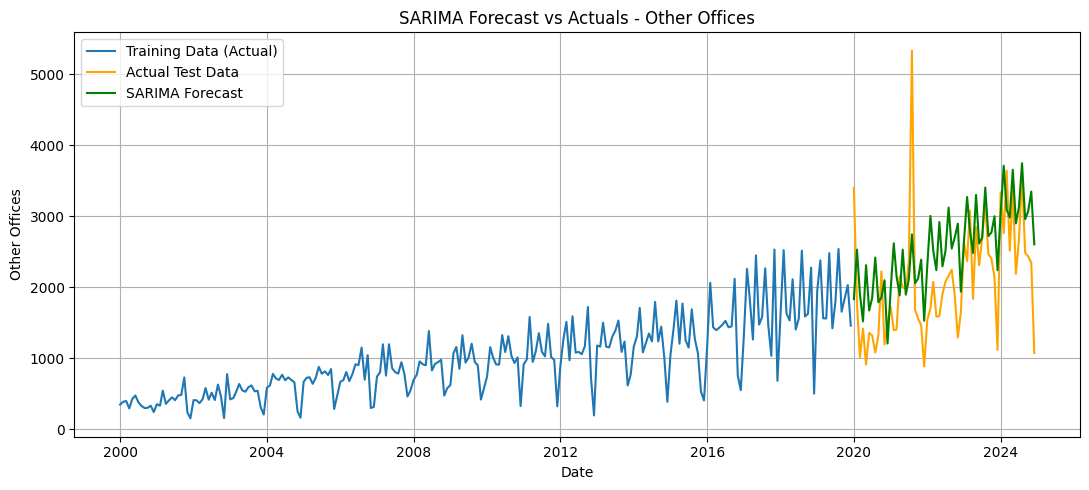

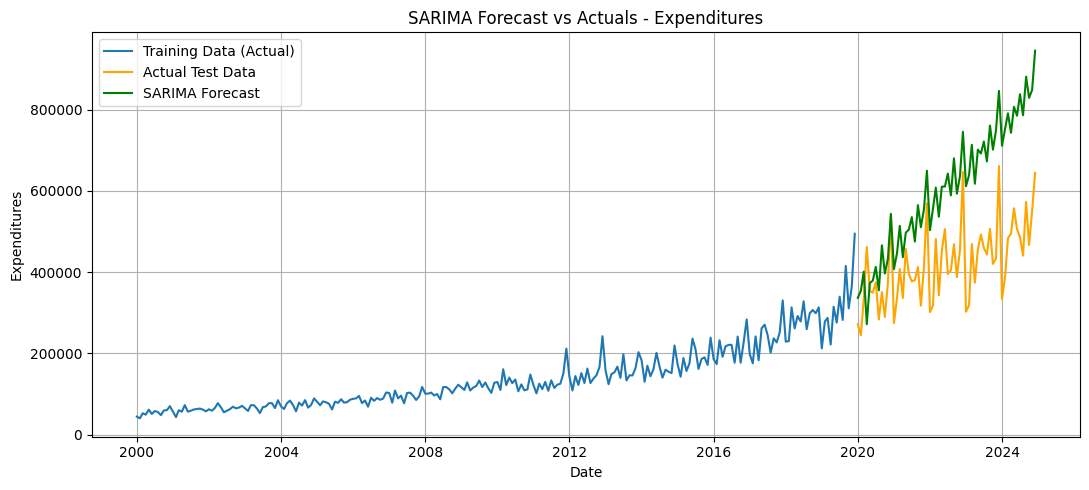

In [10]:
labels_to_plot = [lbl for lbl in labels if lbl in train.columns and lbl in test.columns and lbl in forecasts_df.columns]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train.index, train[lbl], label="Training Data (Actual)")
    plt.plot(test.index, test[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## For 2007

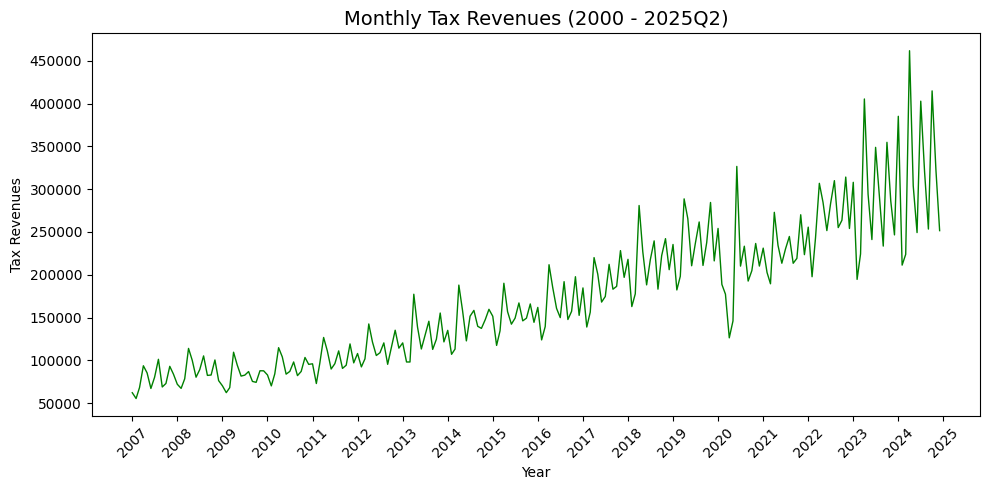

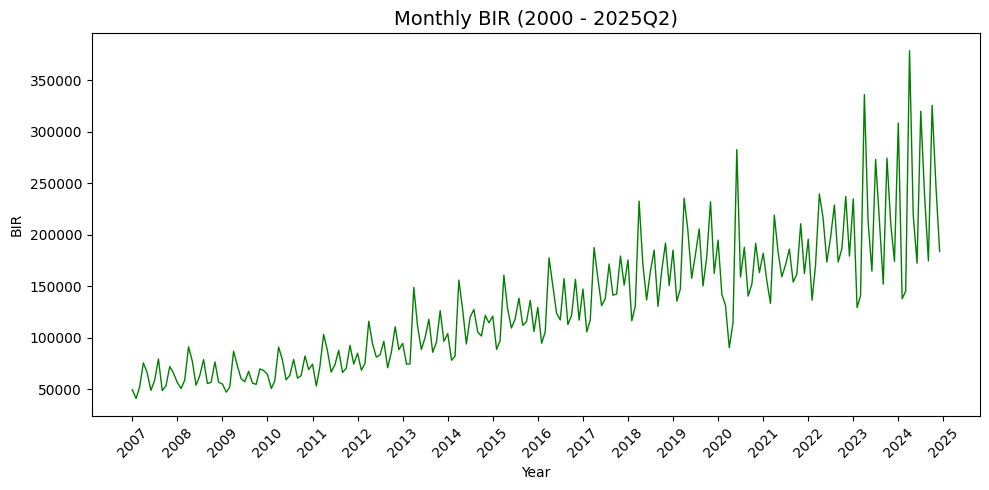

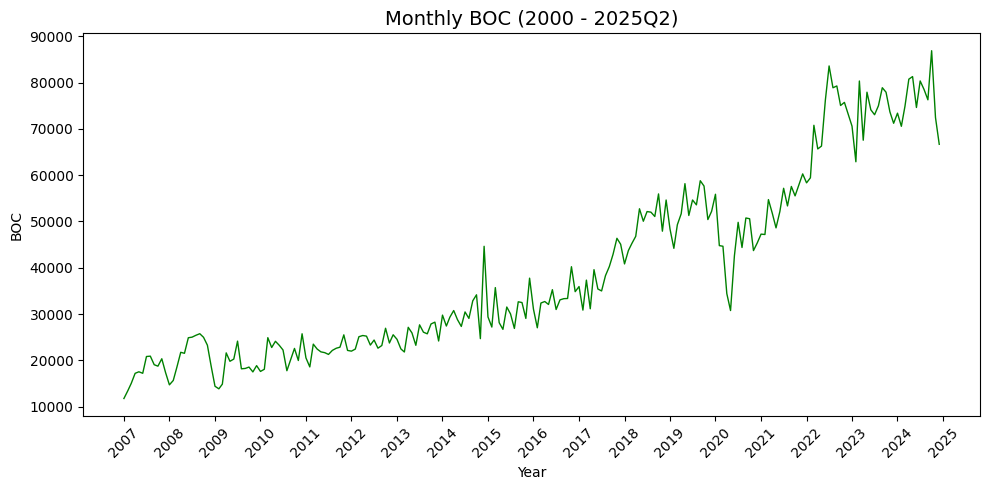

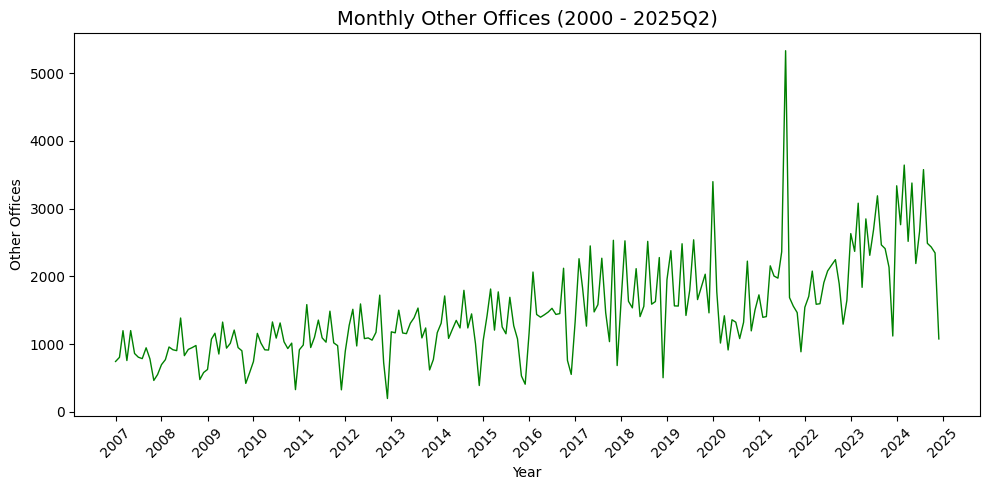

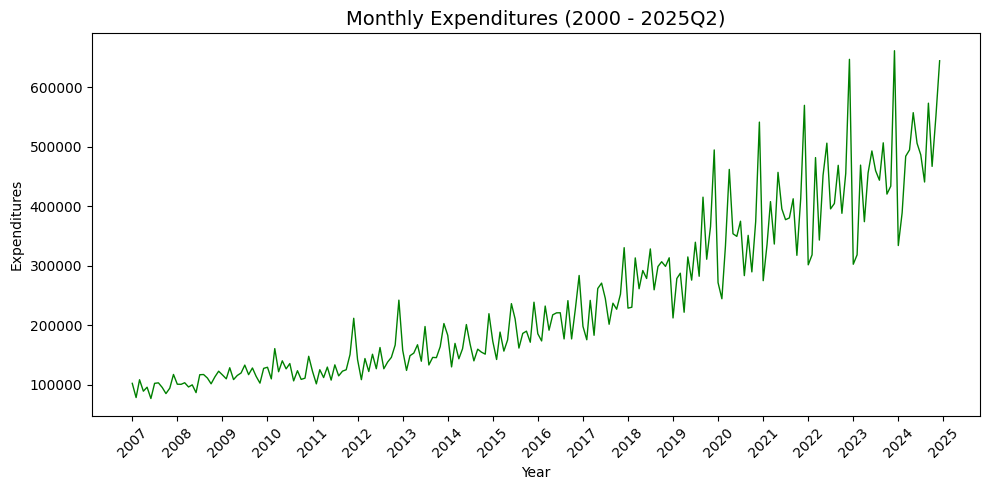

In [11]:
# Prepare data (duplicated from For 1992 section)
data_dir = Path.cwd() / "Data"
cordata = pd.read_csv(data_dir / "cordata.csv")
macro = pd.read_csv(data_dir / "disaggregated.csv")
dummy = pd.read_csv(data_dir / "dummy.csv")

macro = macro.rename(columns={"Unnamed: 3": "Date"})
features = pd.merge(macro, dummy, on="Date", how="left")
dummy_cols = [c for c in dummy.columns if c != "Date"]
features[dummy_cols] = features[dummy_cols].fillna(0)

target = cordata[["Date", "BIR", "BOC", "Other Offices", "Non-tax Revenues", "Expenditures"]]
features = features[["Date", "Inflation", "Imports", "Exports", "USDPHP", "NominalGDP_disagg", "Pop_disagg",
                     "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
target["Tax Revenues"] = target[["BIR", "BOC", "Other Offices"]].sum(axis=1)

target["Date"] = pd.to_datetime(target["Date"])
features["Date"] = pd.to_datetime(features["Date"])

target = target[target["Date"] >= "2007-01-01"]
features = features[features["Date"] >= "2007-01-01"]

target = target.set_index("Date")
features = features.set_index("Date")
features = features.fillna(0)

for x in TARGETS["disaggregated"]["labels"]:
    plot_target(target, x)

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

train = target[:train_size]
test = target[train_size:]

test_num = int(len(target) * 0.20)
train_size = len(target) - test_num

feat_train = features[:train_size]
feat_test = features[train_size:]

records = []



In [12]:
for x in TARGETS["disaggregated"]["labels"]:
    level = adfuller(train[x].dropna())
    first_diff = adfuller(train[x].diff().dropna())
    second_diff = adfuller(train[x].diff().diff().dropna())
    seasonal_diff = adfuller(train[x].diff(12).dropna())
    seasonal_double_diff = adfuller(train[x].diff().diff(12).dropna())

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

pd.DataFrame(records).set_index("Variable")


,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Tax Revenues,0.9666,False,0.0000,True,0.0,True,0.2414,False,0.0000,True
BIR,0.9719,False,0.0000,True,0.0,True,0.1622,False,0.0000,True
BOC,0.8386,False,0.0000,True,0.0,True,0.0115,True,0.0002,True
Other Offices,0.6949,False,0.0000,True,0.0,True,0.0000,True,0.0000,True
Expenditures,1.0000,False,0.0035,True,0.0,True,0.3981,False,0.0000,True


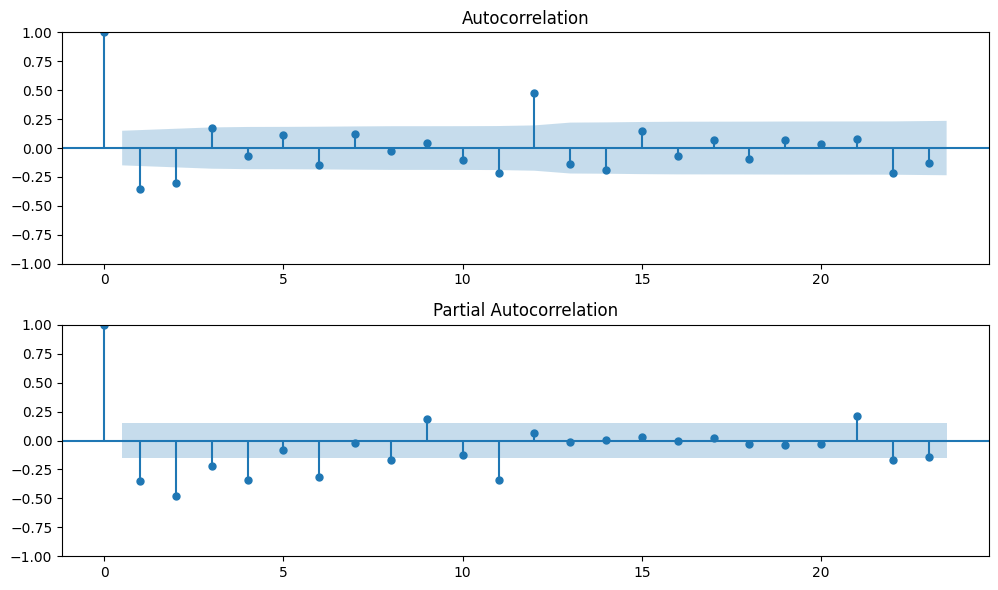

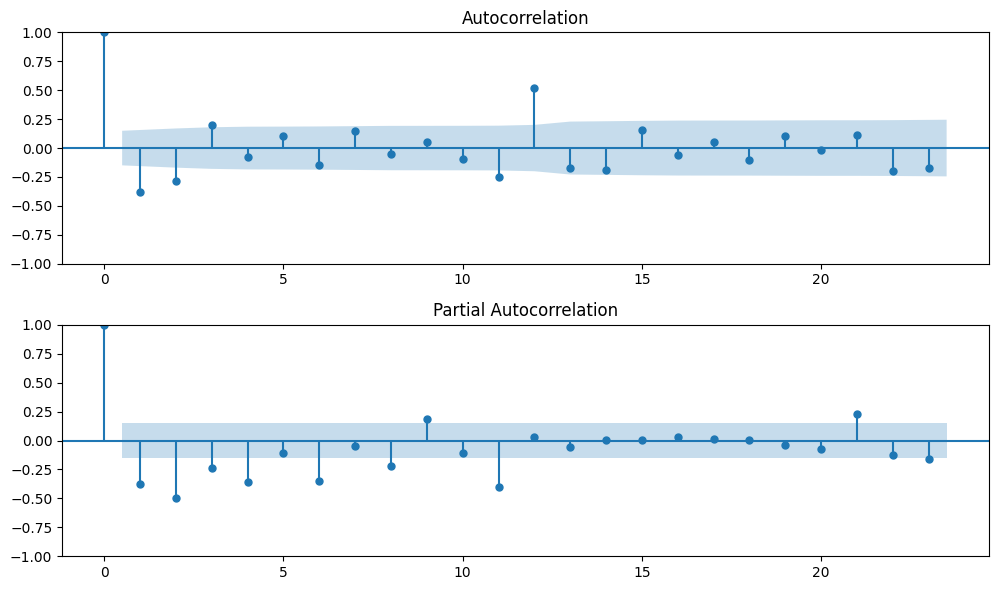

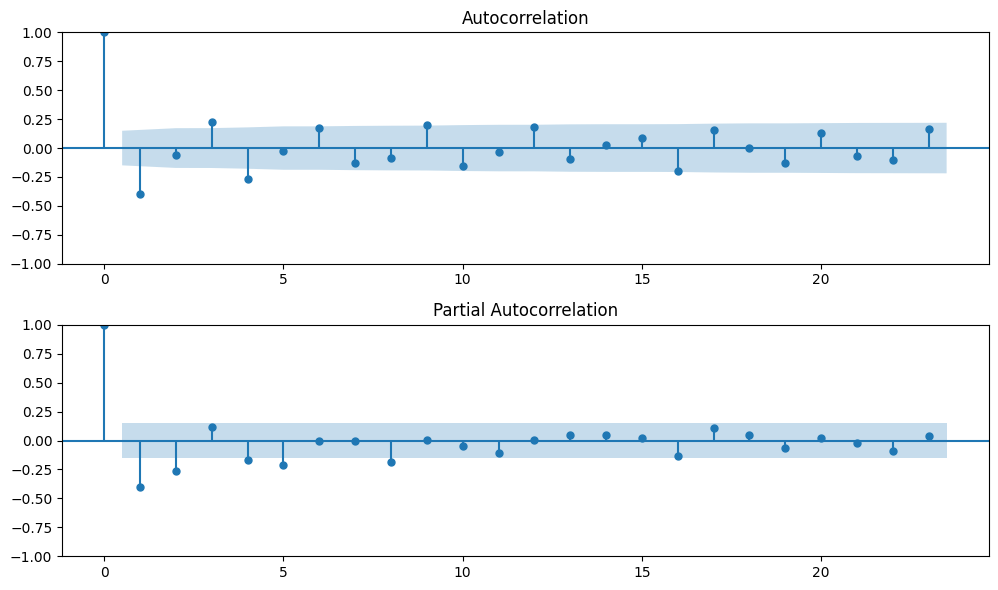

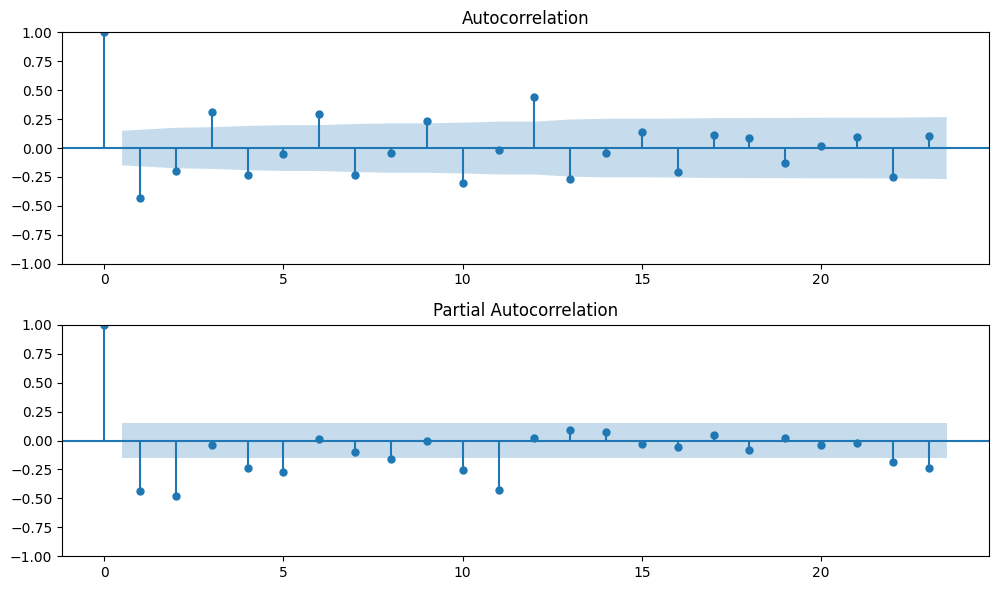

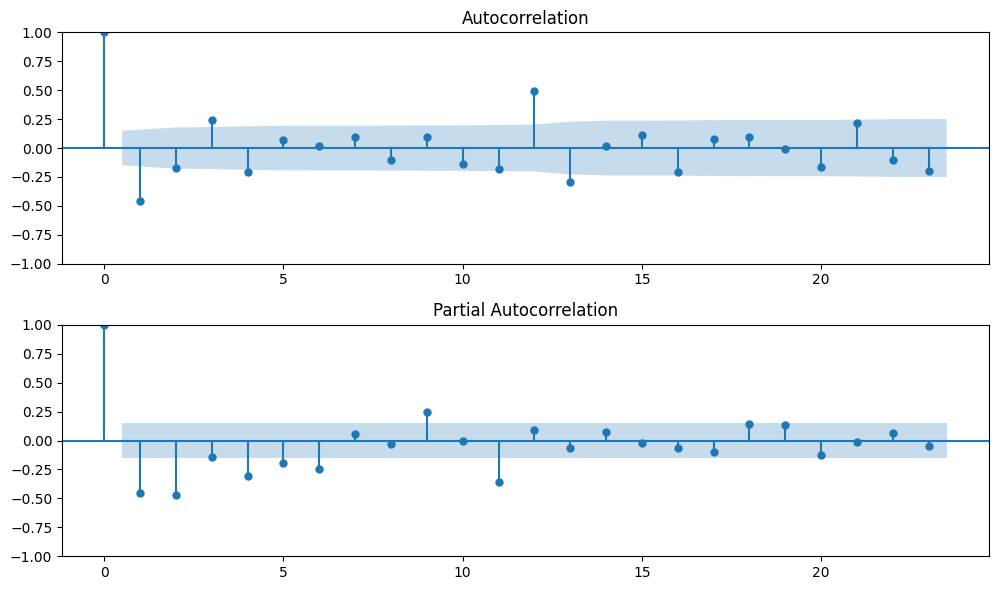

In [13]:
diff_tax_train = train["Tax Revenues"].diff().dropna()
diff_BIR_train = train["BIR"].diff().dropna()
diff_BOC_train = train["BOC"].diff().dropna()
diff_other_offices_train = train["Other Offices"].diff().dropna()
diff_expenditure_train = train["Expenditures"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_tax_train.dropna(), ax=ax[0])
plot_pacf(diff_tax_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BIR_train.dropna(), ax=ax[0])
plot_pacf(diff_BIR_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_BOC_train.dropna(), ax=ax[0])
plot_pacf(diff_BOC_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_other_offices_train.dropna(), ax=ax[0])
plot_pacf(diff_other_offices_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_expenditure_train.dropna(), ax=ax[0])
plot_pacf(diff_expenditure_train.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()


In [14]:
tax_train = train["Tax Revenues"]
bir_train = train["BIR"]
boc_train = train["BOC"]
others_train = train["Other Offices"]
expenditure_train = train["Expenditures"]
tax_test = test["Tax Revenues"]
bir_test = test["BIR"]
boc_test = test["BOC"]
others_test = test["Other Offices"]
expenditure_test = test["Expenditures"]

macro_train = feat_train[["Imports", "Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]
macro_test = feat_test[["Imports", "Exports", "NominalGDP_disagg", "Pop_disagg", "USDPHP", "COVID-19", "TRAIN", "CREATE", "FIST", "BIR_COMM"]]

labels = TARGETS["disaggregated"]["labels"]

bounds_map = {
    "Tax Revenues":  {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "BIR":           {"p_min": 0, "p_max": 4, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 2, "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "BOC":           {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Other Offices": {"p_min": 0, "p_max": 2, "d_min": 1, "d_max": 2, "q_min": 0, "q_max": 4, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Expenditures":  {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 2, "q_min": 1, "q_max": 1, "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

best_models_df, all_trials_df, forecasts_df, fitted_models = multitarget_sarima(
    train_df=train,
    test_df=test,
    exog_train=macro_train,
    exog_test=macro_test,
    labels=labels,
    bounds_map=bounds_map,
    seasonal_period=12,
    verbose=True,
    n_jobs=max(1, (os.cpu_count() or 2) - 1),
)

display(best_models_df)
display(forecasts_df.head())

[Tax Revenues] candidates: 240
[BIR] candidates: 240
[BOC] candidates: 144
[Other Offices] candidates: 360
[Expenditures] candidates: 48


Labels completed:   0%|          | 0/5 [00:00<?, ?it/s]

[BIR] progress: 50/240
[Tax Revenues] progress: 50/240
[BOC] progress: 50/144
[Other Offices] progress: 50/360
[Expenditures] done: 48/48, converged=48


Labels completed:  20%|██        | 1/5 [04:51<19:24, 291.20s/it]

[BIR] progress: 100/240
[Tax Revenues] progress: 100/240
[BOC] progress: 100/144
[Other Offices] progress: 100/360
[BIR] progress: 150/240
[Tax Revenues] progress: 150/240


...

Labels completed:  80%|████████  | 4/5 [14:52<02:51, 171.25s/it]

[Tax Revenues] done: 240/240, converged=240
[Other Offices] progress: 200/360
[Other Offices] progress: 250/360
[Other Offices] progress: 300/360
[Other Offices] progress: 350/360


[Other Offices] done: 360/360, converged=360


,Best_Order,Best_Seasonal_Order,Best_AIC,MAE,RMSE,MAPE_pct
Target,,,,,,
Expenditures,"(1, 1, 1)","(2, 1, 0, 12)",3233.511940,49812.358440,63434.869629,12.364618
BOC,"(2, 1, 0)","(2, 1, 1, 12)",2565.799682,3009.287330,3862.025806,4.131836
BIR,"(4, 1, 0)","(1, 1, 0, 12)",3244.817511,44354.436138,55613.987620,22.536735
Tax Revenues,"(4, 1, 0)","(1, 1, 0, 12)",3254.725233,46388.450845,58384.353496,17.085246
Other Offices,"(2, 1, 0)","(2, 1, 1, 12)",2015.607389,1976.194842,2186.488326,97.957844


,Expenditures,BOC,BIR,Tax Revenues,Other Offices
Date,,,,,
2021-06-01,407516.009081,54654.750739,197545.588889,253033.356187,1779.453951
2021-07-01,451325.493712,55809.330676,162286.344254,225362.183051,2308.494887
2021-08-01,374596.014438,53468.909037,194292.841719,252233.372042,2451.397926
2021-09-01,426838.198376,57982.435409,150404.273516,216432.230139,1947.583787
2021-10-01,399332.099386,58157.301589,165187.436598,231142.374141,2412.063878


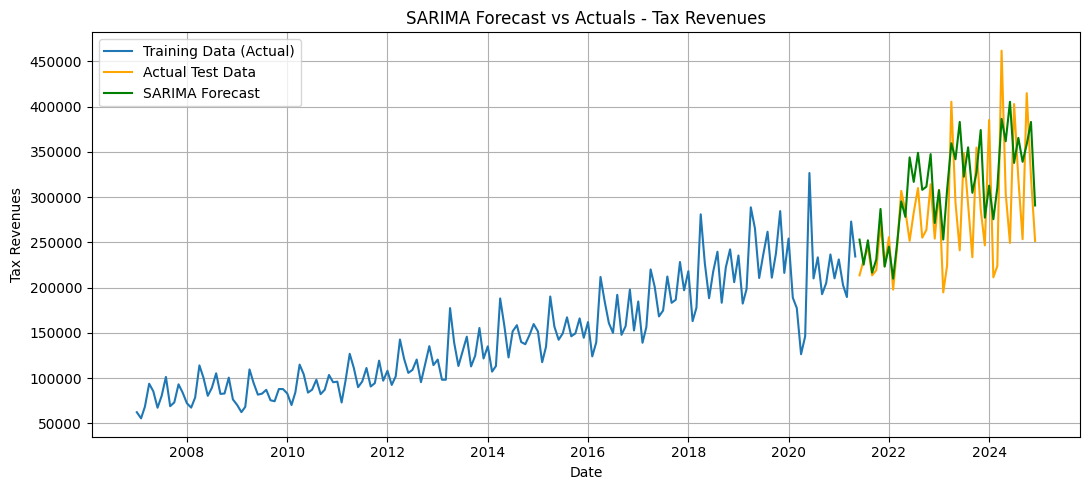

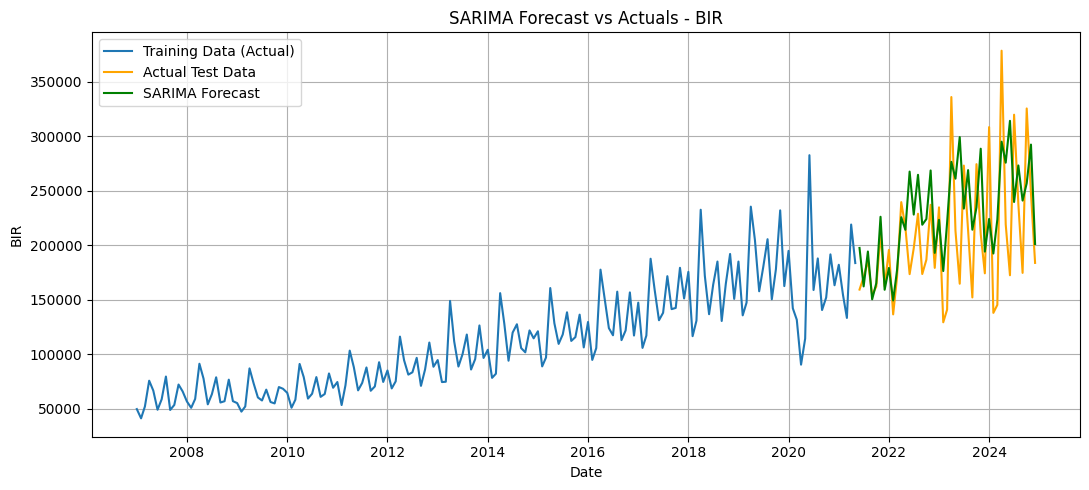

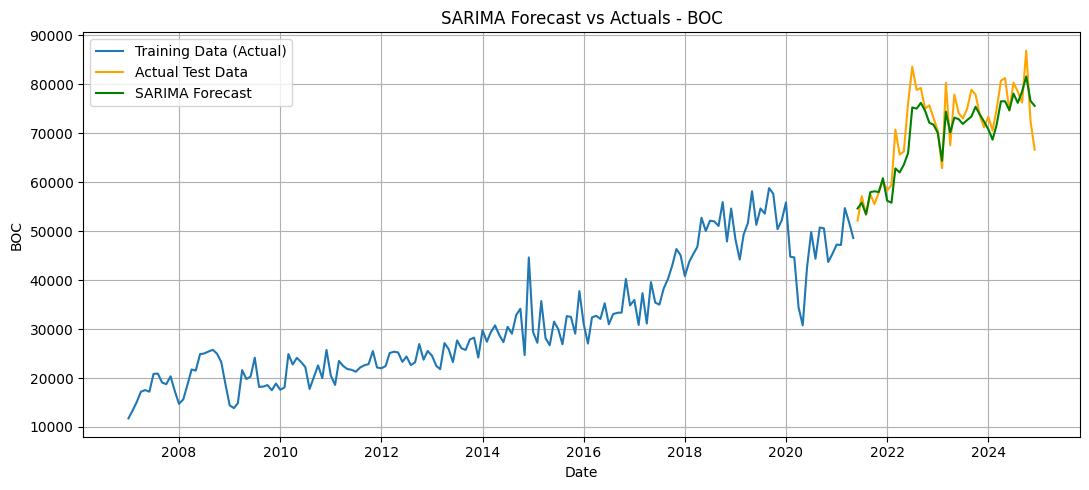

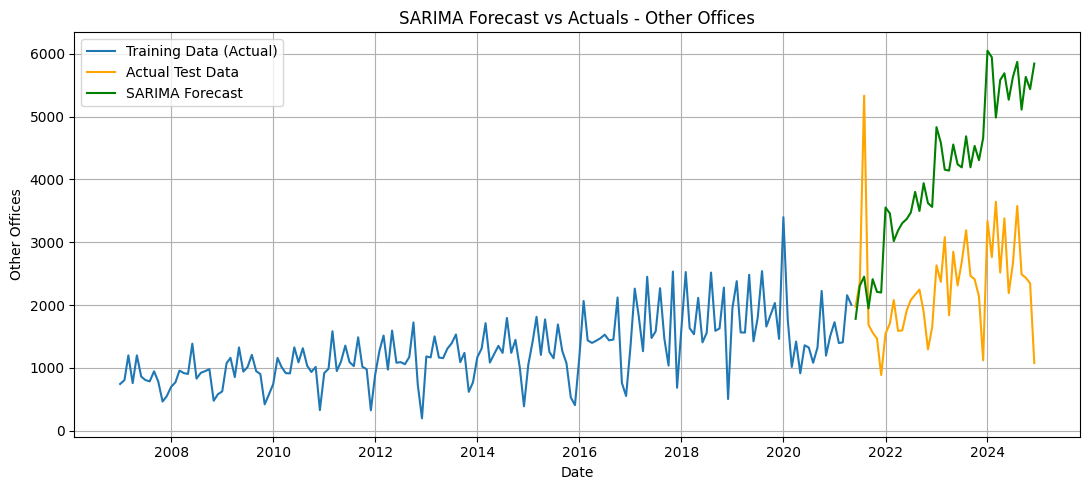

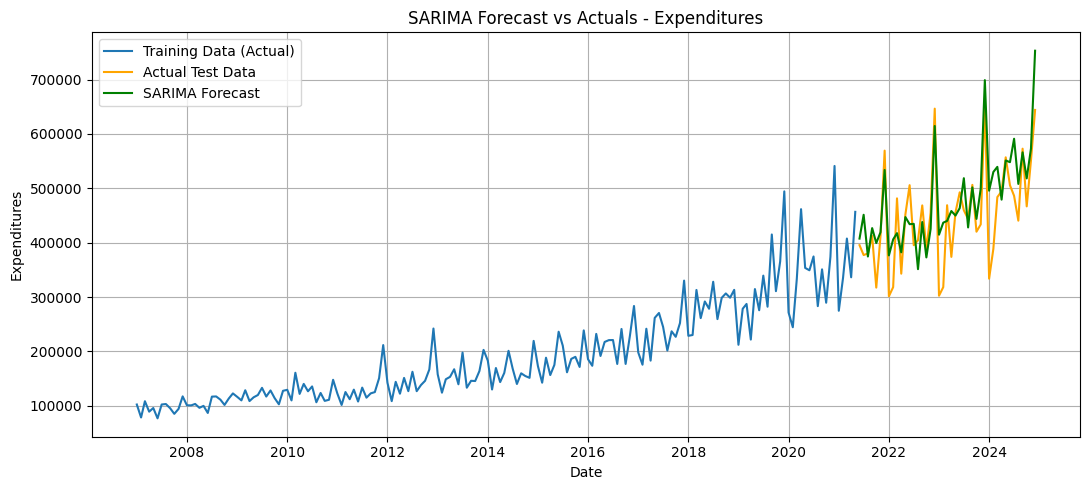

In [15]:
labels_to_plot = [lbl for lbl in labels if lbl in train.columns and lbl in test.columns and lbl in forecasts_df.columns]

if not labels_to_plot:
    raise ValueError("No matching labels found across train/test/forecasts_df.")

for lbl in labels_to_plot:
    plt.figure(figsize=(11, 5))
    plt.plot(train.index, train[lbl], label="Training Data (Actual)")
    plt.plot(test.index, test[lbl], label="Actual Test Data", color="orange")
    plt.plot(forecasts_df.index, forecasts_df[lbl], label="SARIMA Forecast", color="green")
    plt.title(f"SARIMA Forecast vs Actuals - {lbl}")
    plt.xlabel("Date")
    plt.ylabel(lbl)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()